In [1]:
from activation_funcs import *
from error_funcs import *
from initializer import *
from optimizer import *

from Model import MyModel
from layers import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
train_file = pd.read_csv('fashionMnist/fashion-mnist_train.csv')
train_file

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
test_file = pd.read_csv('fashionMnist/fashion-mnist_test.csv')
test_file

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [4]:
idx_set = set(train_file['label'])
idx_set

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [5]:
train_file.info

<bound method DataFrame.info of        label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0          2       0       0       0       0       0       0       0       0   
1          9       0       0       0       0       0       0       0       0   
2          6       0       0       0       0       0       0       0       5   
3          0       0       0       0       1       2       0       0       0   
4          3       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
59995      9       0       0       0       0       0       0       0       0   
59996      1       0       0       0       0       0       0       0       0   
59997      8       0       0       0       0       0       0       0       0   
59998      8       0       0       0       0       0       0       0       0   
59999      7       0       0       0       0       0       0       0       0   

       

In [6]:
x_train = []
y_train = []
for i in range(60000):
    data = np.array(train_file.iloc[i, :])
    x_train.append(data[1:].reshape(28, 28))
    y_train.append(data[0])
x_train = np.array(x_train)
y_train = np.array(y_train)

In [7]:
x_test = []
y_test = []
for i in range(10000):
    data = np.array(test_file.iloc[i, :])
    x_test.append(data[1:].reshape(28, 28))
    y_test.append(data[0])
x_test = np.array(x_test)
y_test = np.array(y_test)

In [8]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [9]:
epoch = 10

In [10]:
def one_hot_encoding(label, max_num=10):
    tmp = [0 for i in range(max_num)]
    tmp[int(label)] = 1
    return tmp

def one_hot_decoding(label):
    return label.index(1)

In [11]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = np.array([one_hot_encoding(i) for i in y_train])

In [12]:
affine_model = MyModel()

affine_model.add_layer(Flatten())
affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.1))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.1))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.1))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.1))
affine_model.add_layer(Softmax())

affine_model.set_loss_func(func=CrossEntropyError())

In [13]:
affine_model.load_data(data_kind='train', x=x_train, y=y_train)
affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [14]:
affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.6155 | Accuracy: 0.7775
start epoch 2
Epoch 2 | Loss: 0.4185 | Accuracy: 0.8467
start epoch 3
Epoch 3 | Loss: 0.3708 | Accuracy: 0.8640
start epoch 4
Epoch 4 | Loss: 0.3425 | Accuracy: 0.8740
start epoch 5
Epoch 5 | Loss: 0.3204 | Accuracy: 0.8825
start epoch 6
Epoch 6 | Loss: 0.3037 | Accuracy: 0.8880
start epoch 7
Epoch 7 | Loss: 0.2891 | Accuracy: 0.8932
start epoch 8
Epoch 8 | Loss: 0.2755 | Accuracy: 0.8979
start epoch 9
Epoch 9 | Loss: 0.2631 | Accuracy: 0.9025
start epoch 10
Epoch 10 | Loss: 0.2530 | Accuracy: 0.9073


In [15]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.8830


In [16]:
test_affine_model = MyModel()

test_affine_model.add_layer(Flatten())
test_affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.45))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.35))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.25))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.15))
test_affine_model.add_layer(Softmax())

test_affine_model.set_loss_func(func=CrossEntropyError())

In [17]:
test_affine_model.load_data(data_kind='train', x=x_train, y=y_train)
test_affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
test_affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [18]:
test_affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.6375 | Accuracy: 0.7629
start epoch 2
Epoch 2 | Loss: 0.4163 | Accuracy: 0.8449
start epoch 3
Epoch 3 | Loss: 0.3706 | Accuracy: 0.8629
start epoch 4
Epoch 4 | Loss: 0.3401 | Accuracy: 0.8748
start epoch 5
Epoch 5 | Loss: 0.3177 | Accuracy: 0.8812
start epoch 6
Epoch 6 | Loss: 0.3005 | Accuracy: 0.8884
start epoch 7
Epoch 7 | Loss: 0.2887 | Accuracy: 0.8918
start epoch 8
Epoch 8 | Loss: 0.2742 | Accuracy: 0.8962
start epoch 9
Epoch 9 | Loss: 0.2629 | Accuracy: 0.9016
start epoch 10
Epoch 10 | Loss: 0.2550 | Accuracy: 0.9036


In [19]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = test_affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.8846


In [21]:
affine_resnet_model = MyModel()
affine_resnet_model.add_layer(Flatten())
affine_resnet_model.add_layer(Affine_ResNet(size=784, learning_rate=0.08))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.08))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine_ResNet(size=300, learning_rate=0.08))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.05))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine_ResNet(size=100, learning_rate=0.05))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine(input_size=100, output_size=10, learning_rate=0.03))
affine_resnet_model.add_layer(Softmax())
affine_resnet_model.set_loss_func(CrossEntropyError())
affine_resnet_model.load_data(data_kind='train', x=x_train, y=y_train)
affine_resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
affine_resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)
affine_resnet_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.6538 | Accuracy: 0.7717
start epoch 2
Epoch 2 | Loss: 0.3948 | Accuracy: 0.8543
start epoch 3
Epoch 3 | Loss: 0.3388 | Accuracy: 0.8746
start epoch 4
Epoch 4 | Loss: 0.3046 | Accuracy: 0.8873
start epoch 5
Epoch 5 | Loss: 0.2772 | Accuracy: 0.8982
start epoch 6
Epoch 6 | Loss: 0.2540 | Accuracy: 0.9063
start epoch 7
Epoch 7 | Loss: 0.2357 | Accuracy: 0.9123
start epoch 8
Epoch 8 | Loss: 0.2580 | Accuracy: 0.9090
start epoch 9
Epoch 9 | Loss: 0.2128 | Accuracy: 0.9211
start epoch 10
Epoch 10 | Loss: 0.1955 | Accuracy: 0.9272


In [22]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = affine_resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.8885


In [23]:
cnn_model = MyModel()

cnn_model.add_layer(Conv(filter_num=20, filter_channels=1, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.08)) # 28x28 
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 14x14 -> (N, C, H, W) = (batch, 20, 14, 14)
cnn_model.add_layer(Conv(filter_num=20, filter_channels=20, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.08)) # 14x14
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 7x7 -> (N, C, H, W) = (batch, 20, 7, 7)
cnn_model.add_layer(Flatten())
cnn_model.add_layer(Affine(input_size=980, output_size=50, learning_rate=0.05)) # 20*7x7=980
cnn_model.add_layer(Relu())
cnn_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.05))
cnn_model.add_layer(Softmax())

cnn_model.set_loss_func(func=CrossEntropyError())

In [24]:
x_train_cnn = x_train.reshape(-1, 1, 28, 28)
x_test_cnn = x_test.reshape(-1, 1, 28, 28)
cnn_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
cnn_model.data_batch_setting(setting_data='x_train', batch_size=100)
cnn_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [25]:
cnn_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.5673 | Accuracy: 0.7971
start epoch 2
Epoch 2 | Loss: 0.3791 | Accuracy: 0.8639
start epoch 3
Epoch 3 | Loss: 0.3347 | Accuracy: 0.8797
start epoch 4
Epoch 4 | Loss: 0.3078 | Accuracy: 0.8901
start epoch 5
Epoch 5 | Loss: 0.2882 | Accuracy: 0.8963
start epoch 6
Epoch 6 | Loss: 0.2728 | Accuracy: 0.9018
start epoch 7
Epoch 7 | Loss: 0.2598 | Accuracy: 0.9067
start epoch 8
Epoch 8 | Loss: 0.2486 | Accuracy: 0.9107
start epoch 9
Epoch 9 | Loss: 0.2387 | Accuracy: 0.9137
start epoch 10
Epoch 10 | Loss: 0.2299 | Accuracy: 0.9175


In [26]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = cnn_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9100


In [43]:
resnet_model = MyModel()

resnet_model.add_layer(Conv(filter_num=20, filter_channels=1, filter_height=3, filter_width=3)) # 28x28
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock(20, 3, 3)) # 28x28
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock(20, 3, 3))
resnet_model.add_layer(Relu())
resnet_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 14x14
resnet_model.add_layer(Flatten())
resnet_model.add_layer(Affine(input_size=3380, output_size=10)) # 사이즈 연산 과정은 아래 주석 참고
resnet_model.add_layer(Softmax())

resnet_model.set_loss_func(func=CrossEntropyError())

In [44]:
resnet_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [45]:
resnet_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.6051 | Accuracy: 0.7901
start epoch 2
Epoch 2 | Loss: 0.4131 | Accuracy: 0.8551
start epoch 3
Epoch 3 | Loss: 0.3677 | Accuracy: 0.8718
start epoch 4
Epoch 4 | Loss: 0.3391 | Accuracy: 0.8811
start epoch 5
Epoch 5 | Loss: 0.3179 | Accuracy: 0.8884
start epoch 6
Epoch 6 | Loss: 0.3010 | Accuracy: 0.8938
start epoch 7
Epoch 7 | Loss: 0.2868 | Accuracy: 0.8991
start epoch 8
Epoch 8 | Loss: 0.2750 | Accuracy: 0.9032
start epoch 9
Epoch 9 | Loss: 0.2643 | Accuracy: 0.9068
start epoch 10
Epoch 10 | Loss: 0.2550 | Accuracy: 0.9102


In [46]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9051


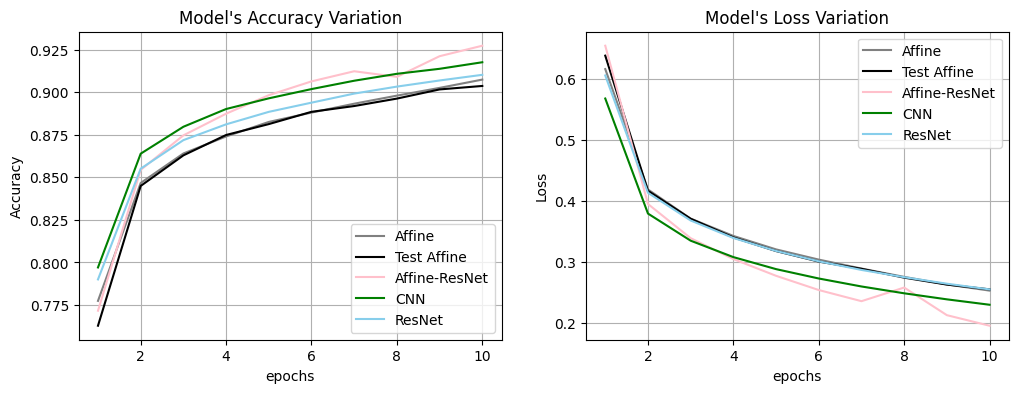

In [47]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot([i+1 for i in range(epoch)], affine_model.acc_log, label='Affine', color='gray')
ax1.plot([i+1 for i in range(epoch)], test_affine_model.acc_log, label='Test Affine', color='black')
ax1.plot([i+1 for i in range(epoch)], affine_resnet_model.acc_log, label='Affine-ResNet', color='pink')
ax1.plot([i+1 for i in range(epoch)], cnn_model.acc_log, label='CNN', color='green')
ax1.plot([i+1 for i in range(epoch)], resnet_model.acc_log, label='ResNet', color='skyblue')
ax1.set_title("Model's Accuracy Variation")
ax1.set_xlabel("epochs")
ax1.set_ylabel("Accuracy")
ax1.grid()
ax1.legend()

ax2.plot([i+1 for i in range(epoch)], affine_model.loss_log, label='Affine', color='gray')
ax2.plot([i+1 for i in range(epoch)], test_affine_model.loss_log, label='Test Affine', color='black')
ax2.plot([i+1 for i in range(epoch)], affine_resnet_model.loss_log, label='Affine-ResNet', color='pink')
ax2.plot([i+1 for i in range(epoch)], cnn_model.loss_log, label='CNN', color='green')
ax2.plot([i+1 for i in range(epoch)], resnet_model.loss_log, label='ResNet', color='skyblue')
ax2.set_title("Model's Loss Variation")
ax2.set_xlabel("epochs")
ax2.set_ylabel("Loss")
ax2.grid()
ax2.legend()

plt.show()